In [37]:
import pandas as pd
import numpy as np

# Load the prepared modeling dataset
feature_data = pd.read_csv(
    "../data/processed/modeling_dataset.csv",
    low_memory=False
)

print("Dataset shape:", feature_data.shape)
print(feature_data.head())

Dataset shape: (96470, 30)
                           order_id                       customer_id  \
0  bfbd0f9bdef84302105ad712db648a6c  86dc2ffce2dfff336de2f386a786e574   
1  d207cc272675637bfed0062edffd0818  b8cf418e97ae795672d326288dfab7a7   
2  ae8a60e4b03c5a4ba9ca0672c164b181  e6f959bf384d1d53b6d68826699bba12   
3  cd3b8574c82b42fc8129f6d502690c3e  7812fcebfc5e8065d31e1bb5f0017dae   
4  a41c8759fbe7aab36ea07e038b2d4465  6f989332712d3222b6571b1cf5b835ce   

   purchase_year  purchase_month  purchase_day  purchase_dayofweek  \
0           2016               9            15                   3   
1           2016              10             3                   0   
2           2016              10             3                   0   
3           2016              10             3                   0   
4           2016              10             3                   0   

   purchase_hour  is_weekend  estimated_delivery_days  delivered_late  ...  \
0             12           0       

In [38]:
# Define target and modeling features

target = "delivered_late"

feature_columns = [
    "purchase_year",
    "purchase_month",
    "purchase_day",
    "purchase_dayofweek",
    "purchase_hour",
    "is_weekend",
    "estimated_delivery_days",
    "total_items",
    "total_price",
    "total_freight",
    "average_item_price",
    "unique_sellers",
    "unique_seller_states",
    "same_state",
    "total_payment_value",
    "max_installments",
    "unique_product_categories",
    "average_product_weight_g",
    "total_product_weight_g",
    "average_product_volume_cm3",
    "total_product_volume_cm3",
    "average_product_photos",
    "seller_previous_orders",
    "seller_previous_late",
    "seller_previous_late_rate"
]

X = feature_data[feature_columns]
y = feature_data[target]

print("Number of features:", len(feature_columns))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(feature_columns)

Number of features: 25
X shape: (96470, 25)
y shape: (96470,)

Features:
['purchase_year', 'purchase_month', 'purchase_day', 'purchase_dayofweek', 'purchase_hour', 'is_weekend', 'estimated_delivery_days', 'total_items', 'total_price', 'total_freight', 'average_item_price', 'unique_sellers', 'unique_seller_states', 'same_state', 'total_payment_value', 'max_installments', 'unique_product_categories', 'average_product_weight_g', 'total_product_weight_g', 'average_product_volume_cm3', 'total_product_volume_cm3', 'average_product_photos', 'seller_previous_orders', 'seller_previous_late', 'seller_previous_late_rate']


In [39]:
# Time-based train/test split

# Sort chronologically
feature_data = feature_data.sort_values("purchase_date").reset_index(drop=True)

# Create X and y again after sorting
X = feature_data[feature_columns]
y = feature_data[target]

# 80% past data for training, 20% future data for testing
split_index = int(len(feature_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining period:")
print(feature_data["purchase_date"].iloc[0])
print("to")
print(feature_data["purchase_date"].iloc[split_index - 1])

print("\nTesting period:")
print(feature_data["purchase_date"].iloc[split_index])
print("to")
print(feature_data["purchase_date"].iloc[-1])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (77176, 25)
Testing shape: (19294, 25)

Training period:
2016-09-15
to
2018-05-26

Testing period:
2018-05-26
to
2018-08-29

Training target distribution:
delivered_late
0    0.911812
1    0.088188
Name: proportion, dtype: float64

Testing target distribution:
delivered_late
0    0.947134
1    0.052866
Name: proportion, dtype: float64


In [40]:
from sklearn.preprocessing import StandardScaler

# Scale features for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (77176, 25)
Scaled testing shape: (19294, 25)


In [41]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Evaluate Logistic Regression

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

roc_auc = roc_auc_score(y_test, y_prob_logistic)
pr_auc = average_precision_score(y_test, y_prob_logistic)

print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
Accuracy : 0.2885
Precision: 0.0652
Recall   : 0.9333
F1 Score : 0.1218
ROC-AUC  : 0.6192
PR-AUC   : 0.0750

Confusion Matrix:
[[ 4615 13659]
 [   68   952]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.25      0.40     18274
           1       0.07      0.93      0.12      1020

    accuracy                           0.29     19294
   macro avg       0.53      0.59      0.26     19294
weighted avg       0.94      0.29      0.39     19294



In [43]:
# Logistic Regression feature importance

logistic_coefficients = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": logistic_model.coef_[0]
})

logistic_coefficients["absolute_coefficient"] = (
    logistic_coefficients["coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
)

print("Logistic Regression Feature Coefficients:")
print(
    logistic_coefficients[
        ["feature", "coefficient"]
    ].to_string(index=False)
)

Logistic Regression Feature Coefficients:
                   feature  coefficient
                same_state    -0.546568
   estimated_delivery_days    -0.445220
             purchase_year     0.363817
 seller_previous_late_rate     0.248463
        average_item_price     0.228447
             total_freight     0.219751
            purchase_month     0.207159
            unique_sellers    -0.171961
      seller_previous_late     0.141418
       total_payment_value    -0.120619
               total_price    -0.117110
  total_product_volume_cm3    -0.110532
              purchase_day     0.095725
average_product_volume_cm3     0.093362
               total_items    -0.085543
    total_product_weight_g     0.058020
    seller_previous_orders    -0.046567
  average_product_weight_g    -0.040686
      unique_seller_states    -0.037741
    average_product_photos    -0.037446
          max_installments     0.032381
                is_weekend    -0.029854
             purchase_hour     0.02956

In [44]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


In [45]:
# Evaluate Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("Random Forest Results")
print("=" * 40)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")
print(f"PR-AUC   : {pr_auc_rf:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.8002
Precision: 0.0594
Recall   : 0.1873
F1 Score : 0.0902
ROC-AUC  : 0.5448
PR-AUC   : 0.0649

Confusion Matrix:
[[15249  3025]
 [  829   191]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89     18274
           1       0.06      0.19      0.09      1020

    accuracy                           0.80     19294
   macro avg       0.50      0.51      0.49     19294
weighted avg       0.90      0.80      0.85     19294



In [46]:
from xgboost import XGBClassifier

# Calculate class imbalance from training data
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("Scale positive weight:", scale_pos_weight)

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost training completed.")

Scale positive weight: 10.339406406112253
XGBoost training completed.


In [47]:
# Evaluate XGBoost

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("=" * 40)
print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")
print(f"PR-AUC   : {pr_auc_xgb:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy : 0.7289
Precision: 0.0653
Recall   : 0.3098
F1 Score : 0.1078
ROC-AUC  : 0.5505
PR-AUC   : 0.0607

Confusion Matrix:
[[13748  4526]
 [  704   316]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     18274
           1       0.07      0.31      0.11      1020

    accuracy                           0.73     19294
   macro avg       0.51      0.53      0.47     19294
weighted avg       0.90      0.73      0.80     19294



In [48]:
# XGBoost feature importance

xgb_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "importance",
    ascending=False
)

print("XGBoost Feature Importance:")
print(xgb_importance.to_string(index=False))

XGBoost Feature Importance:
                   feature  importance
                same_state    0.169472
             purchase_year    0.105683
            purchase_month    0.089394
 seller_previous_late_rate    0.082369
            unique_sellers    0.064097
   estimated_delivery_days    0.044899
               total_items    0.043736
             total_freight    0.039588
              purchase_day    0.030815
      seller_previous_late    0.028036
average_product_volume_cm3    0.023546
  average_product_weight_g    0.023402
    seller_previous_orders    0.022756
        average_item_price    0.022756
  total_product_volume_cm3    0.022399
    total_product_weight_g    0.021766
       total_payment_value    0.020731
 unique_product_categories    0.020400
               total_price    0.019576
             purchase_hour    0.019507
        purchase_dayofweek    0.019336
    average_product_photos    0.018691
          max_installments    0.016547
                is_weekend    0.0157

In [49]:
# Create a reduced feature set by removing low-importance features

reduced_features = [
    "same_state",
    "purchase_year",
    "purchase_month",
    "seller_previous_late_rate",
    "unique_sellers",
    "estimated_delivery_days",
    "total_items",
    "total_freight",
    "purchase_day",
    "seller_previous_late",
    "average_product_volume_cm3",
    "average_product_weight_g",
    "seller_previous_orders",
    "average_item_price",
    "total_product_volume_cm3",
    "total_product_weight_g",
    "total_payment_value",
    "unique_product_categories",
    "total_price",
    "purchase_hour",
    "purchase_dayofweek",
    "average_product_photos",
    "max_installments",
    "is_weekend",
    "unique_seller_states"
]

X_reduced = feature_data[reduced_features]

X_train_reduced = X_reduced.iloc[:split_index]
X_test_reduced = X_reduced.iloc[split_index:]

print("Reduced feature count:", len(reduced_features))
print("Reduced training shape:", X_train_reduced.shape)
print("Reduced testing shape:", X_test_reduced.shape)

Reduced feature count: 25
Reduced training shape: (77176, 25)
Reduced testing shape: (19294, 25)


In [50]:
# Select top 15 XGBoost features

top_features = xgb_importance.head(15)["feature"].tolist()

print("Top 15 features:")
for i, feature in enumerate(top_features, start=1):
    print(f"{i}. {feature}")

X_top = feature_data[top_features]

X_train_top = X_top.iloc[:split_index]
X_test_top = X_top.iloc[split_index:]

print("\nTop feature count:", len(top_features))
print("Training shape:", X_train_top.shape)
print("Testing shape:", X_test_top.shape)

Top 15 features:
1. same_state
2. purchase_year
3. purchase_month
4. seller_previous_late_rate
5. unique_sellers
6. estimated_delivery_days
7. total_items
8. total_freight
9. purchase_day
10. seller_previous_late
11. average_product_volume_cm3
12. average_product_weight_g
13. seller_previous_orders
14. average_item_price
15. total_product_volume_cm3

Top feature count: 15
Training shape: (77176, 15)
Testing shape: (19294, 15)


In [51]:
# Train XGBoost using top 15 features

xgb_top_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_top_model.fit(X_train_top, y_train)

# Predictions
y_pred_xgb_top = xgb_top_model.predict(X_test_top)
y_prob_xgb_top = xgb_top_model.predict_proba(X_test_top)[:, 1]

print("Top-15 XGBoost training completed.")

Top-15 XGBoost training completed.


In [52]:
# Evaluate Top-15 XGBoost

accuracy_xgb_top = accuracy_score(y_test, y_pred_xgb_top)
precision_xgb_top = precision_score(y_test, y_pred_xgb_top)
recall_xgb_top = recall_score(y_test, y_pred_xgb_top)
f1_xgb_top = f1_score(y_test, y_pred_xgb_top)

roc_auc_xgb_top = roc_auc_score(y_test, y_prob_xgb_top)
pr_auc_xgb_top = average_precision_score(y_test, y_prob_xgb_top)

print("Top-15 XGBoost Results")
print("=" * 40)
print(f"Accuracy : {accuracy_xgb_top:.4f}")
print(f"Precision: {precision_xgb_top:.4f}")
print(f"Recall   : {recall_xgb_top:.4f}")
print(f"F1 Score : {f1_xgb_top:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb_top:.4f}")
print(f"PR-AUC   : {pr_auc_xgb_top:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_top))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_top))

Top-15 XGBoost Results
Accuracy : 0.7223
Precision: 0.0672
Recall   : 0.3304
F1 Score : 0.1117
ROC-AUC  : 0.5625
PR-AUC   : 0.0635

Confusion Matrix:
[[13599  4675]
 [  683   337]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.74      0.84     18274
           1       0.07      0.33      0.11      1020

    accuracy                           0.72     19294
   macro avg       0.51      0.54      0.47     19294
weighted avg       0.91      0.72      0.80     19294



In [53]:
# Create a chronological validation split inside the training data

validation_split_index = int(len(X_train_top) * 0.80)

X_train_inner = X_train_top.iloc[:validation_split_index]
X_validation = X_train_top.iloc[validation_split_index:]

y_train_inner = y_train.iloc[:validation_split_index]
y_validation = y_train.iloc[validation_split_index:]

print("Inner training shape:", X_train_inner.shape)
print("Validation shape:", X_validation.shape)

print("\nInner training period:")
print(feature_data["purchase_date"].iloc[0])
print("to")
print(
    feature_data["purchase_date"]
    .iloc[validation_split_index - 1]
)

print("\nValidation period:")
print(
    feature_data["purchase_date"]
    .iloc[validation_split_index]
)
print("to")
print(
    feature_data["purchase_date"]
    .iloc[split_index - 1]
)

print("\nValidation target distribution:")
print(y_validation.value_counts(normalize=True))

Inner training shape: (61740, 15)
Validation shape: (15436, 15)

Inner training period:
2016-09-15
to
2018-03-20

Validation period:
2018-03-20
to
2018-05-26

Validation target distribution:
delivered_late
0    0.918761
1    0.081239
Name: proportion, dtype: float64


In [54]:
# Train XGBoost on inner training data

xgb_validation_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_validation_model.fit(
    X_train_inner,
    y_train_inner
)

# Validation probabilities
y_prob_validation = xgb_validation_model.predict_proba(
    X_validation
)[:, 1]

print("Validation XGBoost training completed.")

Validation XGBoost training completed.


In [55]:
from sklearn.metrics import average_precision_score, roc_auc_score

# Evaluate validation probabilities

validation_roc_auc = roc_auc_score(
    y_validation,
    y_prob_validation
)

validation_pr_auc = average_precision_score(
    y_validation,
    y_prob_validation
)

print("Validation XGBoost Results")
print("=" * 40)
print(f"ROC-AUC: {validation_roc_auc:.4f}")
print(f"PR-AUC : {validation_pr_auc:.4f}")

Validation XGBoost Results
ROC-AUC: 0.6673
PR-AUC : 0.1633


In [56]:
# Calculate class imbalance using ONLY inner training data

validation_scale_pos_weight = (
    (y_train_inner == 0).sum()
    / (y_train_inner == 1).sum()
)

print(
    "Validation scale_pos_weight:",
    validation_scale_pos_weight
)

Validation scale_pos_weight: 10.120317002881844


In [57]:
# Retrain validation XGBoost with correct class weight

xgb_validation_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=validation_scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_validation_model.fit(
    X_train_inner,
    y_train_inner
)

# Validation probabilities
y_prob_validation = xgb_validation_model.predict_proba(
    X_validation
)[:, 1]

print("Corrected validation XGBoost training completed.")

Corrected validation XGBoost training completed.


In [58]:
# Evaluate corrected validation XGBoost

validation_roc_auc = roc_auc_score(
    y_validation,
    y_prob_validation
)

validation_pr_auc = average_precision_score(
    y_validation,
    y_prob_validation
)

print("Corrected Validation XGBoost Results")
print("=" * 45)
print(f"ROC-AUC: {validation_roc_auc:.4f}")
print(f"PR-AUC : {validation_pr_auc:.4f}")

Corrected Validation XGBoost Results
ROC-AUC: 0.6671
PR-AUC : 0.1629


In [59]:
# XGBoost depth experiment

depth_results = []

for depth in [3, 5, 7]:

    model = XGBClassifier(
        n_estimators=300,
        max_depth=depth,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=validation_scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_inner,
        y_train_inner
    )

    validation_prob = model.predict_proba(
        X_validation
    )[:, 1]

    pr_auc = average_precision_score(
        y_validation,
        validation_prob
    )

    roc_auc = roc_auc_score(
        y_validation,
        validation_prob
    )

    depth_results.append({
        "max_depth": depth,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

depth_results_df = pd.DataFrame(depth_results)

print(depth_results_df)

   max_depth   ROC-AUC    PR-AUC
0          3  0.672434  0.170327
1          5  0.667080  0.162850
2          7  0.645217  0.142765


In [60]:
# XGBoost learning rate experiment

learning_rate_results = []

for lr in [0.03, 0.05, 0.10]:

    model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=validation_scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_inner,
        y_train_inner
    )

    validation_prob = model.predict_proba(
        X_validation
    )[:, 1]

    pr_auc = average_precision_score(
        y_validation,
        validation_prob
    )

    roc_auc = roc_auc_score(
        y_validation,
        validation_prob
    )

    learning_rate_results.append({
        "learning_rate": lr,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

learning_rate_results_df = pd.DataFrame(
    learning_rate_results
)

print(learning_rate_results_df)

   learning_rate   ROC-AUC    PR-AUC
0           0.03  0.676470  0.171358
1           0.05  0.672434  0.170327
2           0.10  0.666855  0.168495


In [61]:
# XGBoost number of estimators experiment

estimator_results = []

for n_estimators in [200, 300, 500]:

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=validation_scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_inner,
        y_train_inner
    )

    validation_prob = model.predict_proba(
        X_validation
    )[:, 1]

    pr_auc = average_precision_score(
        y_validation,
        validation_prob
    )

    roc_auc = roc_auc_score(
        y_validation,
        validation_prob
    )

    estimator_results.append({
        "n_estimators": n_estimators,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

estimator_results_df = pd.DataFrame(
    estimator_results
)

print(estimator_results_df)

   n_estimators   ROC-AUC    PR-AUC
0           200  0.676739  0.170642
1           300  0.676470  0.171358
2           500  0.672832  0.170018


In [62]:
# XGBoost class-weight experiment

class_weight_results = []

for weight in [5, 10, 15]:

    model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_inner,
        y_train_inner
    )

    validation_prob = model.predict_proba(
        X_validation
    )[:, 1]

    pr_auc = average_precision_score(
        y_validation,
        validation_prob
    )

    roc_auc = roc_auc_score(
        y_validation,
        validation_prob
    )

    class_weight_results.append({
        "scale_pos_weight": weight,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

class_weight_results_df = pd.DataFrame(
    class_weight_results
)

print(class_weight_results_df)

   scale_pos_weight   ROC-AUC    PR-AUC
0                 5  0.679270  0.173458
1                10  0.677183  0.172271
2                15  0.673077  0.170594


In [63]:
# Train the currently selected XGBoost model

final_validation_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=5,
    random_state=42,
    n_jobs=-1
)

final_validation_model.fit(
    X_train_inner,
    y_train_inner
)

validation_prob = final_validation_model.predict_proba(
    X_validation
)[:, 1]

print("Validation ROC-AUC:",
      roc_auc_score(y_validation, validation_prob))

print("Validation PR-AUC:",
      average_precision_score(y_validation, validation_prob))

Validation ROC-AUC: 0.679270250021536
Validation PR-AUC: 0.173457770825446


In [64]:
# Threshold optimization on validation set

from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    validation_pred = (
        validation_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision,
        "recall": recall,
        "F1": f1
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

print(threshold_results_df)

    threshold  precision    recall        F1
0        0.10   0.081376  1.000000  0.150504
1        0.15   0.082046  0.999203  0.151640
2        0.20   0.083384  0.990431  0.153818
3        0.25   0.086922  0.965710  0.159489
4        0.30   0.091667  0.947368  0.167159
5        0.35   0.096503  0.906699  0.174440
6        0.40   0.103719  0.862839  0.185179
7        0.45   0.110976  0.799841  0.194909
8        0.50   0.117350  0.721691  0.201874
9        0.55   0.126966  0.637161  0.211740
10       0.60   0.142102  0.557416  0.226470
11       0.65   0.154019  0.437002  0.227764
12       0.70   0.177866  0.322967  0.229397
13       0.75   0.217167  0.201754  0.209177
14       0.80   0.273171  0.089314  0.134615
15       0.85   0.461538  0.019139  0.036753
16       0.90   0.000000  0.000000  0.000000


In [65]:
# Train final XGBoost model on the complete training period

final_scale_pos_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

final_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=5,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_top,
    y_train
)

print("Final model trained.")
print("Training rows:", len(X_train_top))
print("Features:", X_train_top.shape[1])
print("Selected threshold:", 0.70)

Final model trained.
Training rows: 77176
Features: 15
Selected threshold: 0.7


In [66]:
# Final evaluation on the untouched test period

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predict probabilities
test_prob = final_model.predict_proba(
    X_test_top
)[:, 1]

# Apply validation-selected threshold
test_pred = (
    test_prob >= 0.70
).astype(int)

# Probability-based metrics
test_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

# Threshold-based metrics
test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

print("FINAL TEST RESULTS")
print("=" * 40)

print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["On Time / Early", "Late"],
        zero_division=0
    )
)

FINAL TEST RESULTS
ROC-AUC : 0.5937
PR-AUC  : 0.0709
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

Confusion Matrix
[[18272     2]
 [ 1020     0]]

Classification Report
                 precision    recall  f1-score   support

On Time / Early       0.95      1.00      0.97     18274
           Late       0.00      0.00      0.00      1020

       accuracy                           0.95     19294
      macro avg       0.47      0.50      0.49     19294
   weighted avg       0.90      0.95      0.92     19294



In [67]:
# Detailed threshold analysis on validation set

threshold_analysis = []

for threshold in np.arange(0.20, 0.71, 0.05):

    validation_pred = (
        validation_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    predicted_late_rate = validation_pred.mean()

    threshold_analysis.append({
        "threshold": round(threshold, 2),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "F1": round(f1, 4),
        "predicted_late_rate": round(predicted_late_rate, 4)
    })

threshold_analysis_df = pd.DataFrame(
    threshold_analysis
)

print(threshold_analysis_df)

    threshold  precision  recall      F1  predicted_late_rate
0        0.20     0.0834  0.9904  0.1538               0.9650
1        0.25     0.0869  0.9657  0.1595               0.9026
2        0.30     0.0917  0.9474  0.1672               0.8396
3        0.35     0.0965  0.9067  0.1744               0.7633
4        0.40     0.1037  0.8628  0.1852               0.6758
5        0.45     0.1110  0.7998  0.1949               0.5855
6        0.50     0.1173  0.7217  0.2019               0.4996
7        0.55     0.1270  0.6372  0.2117               0.4077
8        0.60     0.1421  0.5574  0.2265               0.3187
9        0.65     0.1540  0.4370  0.2278               0.2305
10       0.70     0.1779  0.3230  0.2294               0.1475


In [68]:
# SHAP explainability

import shap

# Create SHAP TreeExplainer for the final XGBoost model
explainer = shap.TreeExplainer(final_model)

print("SHAP explainer created successfully.")

c:\Users\Sariga\Documents\AIML _Project\OpsPredict\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP explainer created successfully.


In [69]:
# Calculate SHAP values on a test sample

X_shap = X_test_top.sample(
    n=2000,
    random_state=42
)

shap_values = explainer.shap_values(X_shap)

print("SHAP sample shape:", X_shap.shape)
print("SHAP values shape:", shap_values.shape)

SHAP sample shape: (2000, 15)
SHAP values shape: (2000, 15)


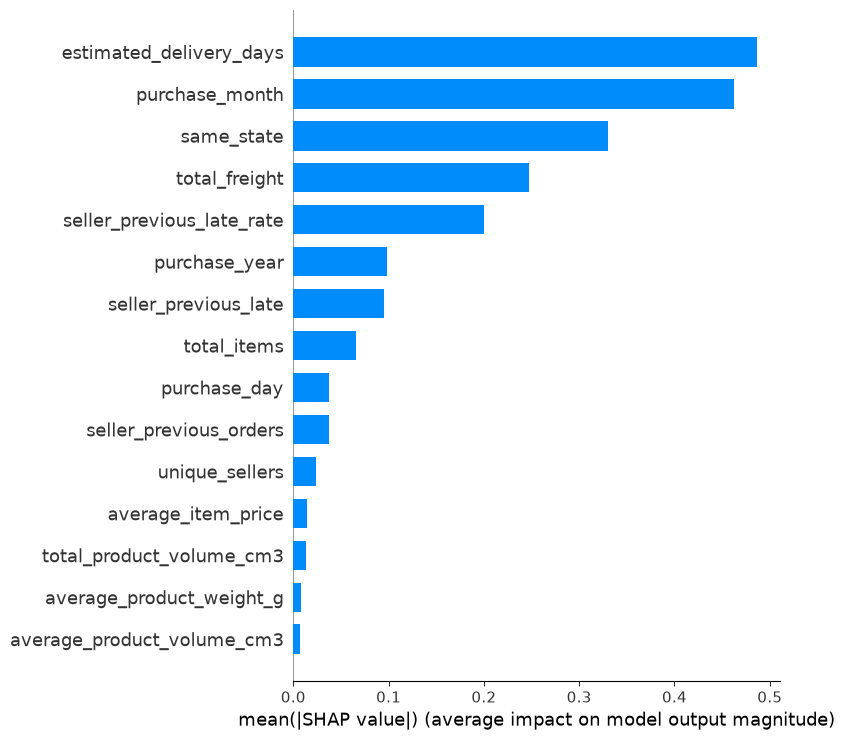

In [70]:
# SHAP feature importance

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=True
)

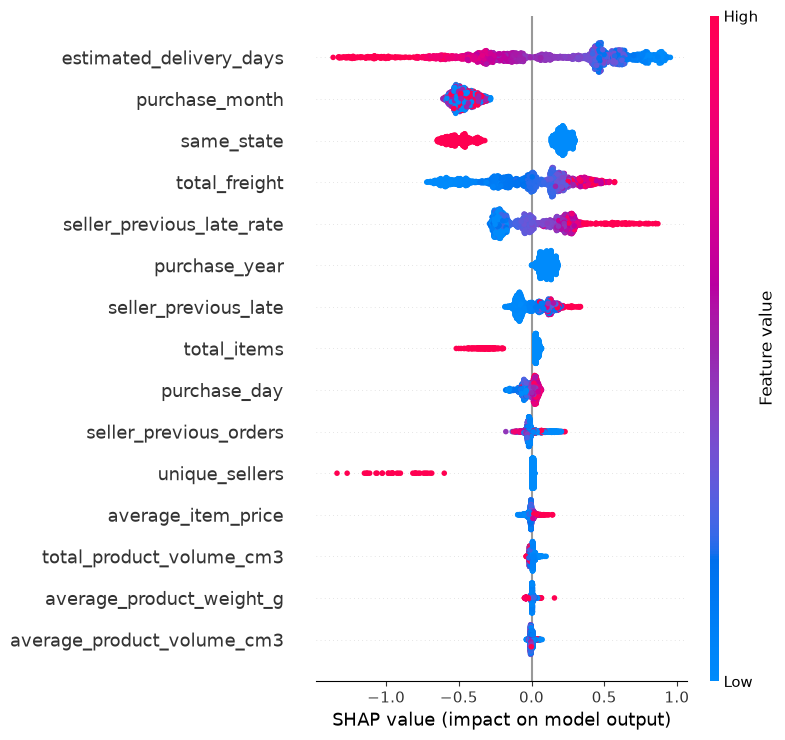

In [71]:
# Detailed SHAP summary plot

shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

In [72]:
# Save SHAP visualizations

import os
import matplotlib.pyplot as plt

os.makedirs("../reports", exist_ok=True)

# SHAP feature importance bar plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig(
    "../reports/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# SHAP detailed beeswarm plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)
plt.tight_layout()
plt.savefig(
    "../reports/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

print("SHAP plots saved successfully.")
print("Saved:")
print("../reports/shap_feature_importance.png")
print("../reports/shap_summary_plot.png")

SHAP plots saved successfully.
Saved:
../reports/shap_feature_importance.png
../reports/shap_summary_plot.png


In [74]:
# MLflow setup

import mlflow
import mlflow.xgboost

mlflow.set_experiment("OpsPredict_Delivery_Risk")

print("MLflow experiment configured.")

MLflow experiment configured.


In [75]:
# Log final OpsPredict model to MLflow

with mlflow.start_run(run_name="OpsPredict_Final_XGBoost"):

    # Log model parameters
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("learning_rate", 0.03)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("scale_pos_weight", 5)
    mlflow.log_param("feature_count", X_train_top.shape[1])
    mlflow.log_param("decision_threshold", 0.70)

    # Log validation metrics
    mlflow.log_metric("validation_roc_auc", 0.6792702500)
    mlflow.log_metric("validation_pr_auc", 0.1734577708)

    # Log final test metrics
    mlflow.log_metric("test_roc_auc", test_roc_auc)
    mlflow.log_metric("test_pr_auc", test_pr_auc)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_f1", test_f1)

    # Log the trained XGBoost model
    mlflow.xgboost.log_model(
        final_model,
        name="ops_predict_xgboost_model"
    )

    print("Final OpsPredict model logged to MLflow.")
    print("Run ID:", mlflow.active_run().info.run_id)

Final OpsPredict model logged to MLflow.
Run ID: b3a778d6c3704c91a4da7002f19ac460


In [76]:
# Save final model locally

import os
import joblib

os.makedirs("../models", exist_ok=True)

model_path = "../models/ops_predict_xgboost.pkl"

joblib.dump(
    final_model,
    model_path
)

print("Model saved successfully.")
print("Path:", model_path)

Model saved successfully.
Path: ../models/ops_predict_xgboost.pkl


In [77]:
# Save model metadata for FastAPI

import json

model_metadata = {
    "model_type": "XGBoost",
    "features": top_features,
    "threshold": 0.70
}

metadata_path = "../models/model_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(model_metadata, f, indent=4)

print("Model metadata saved successfully.")
print("Features:", len(top_features))
print("Threshold:", model_metadata["threshold"])
print("Path:", metadata_path)

Model metadata saved successfully.
Features: 15
Threshold: 0.7
Path: ../models/model_metadata.json
